In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)


In [29]:
data_path = Path("/Users/tsantaloic/Desktop/Projet_05_AIA02/data/raw")

dfs = []

for file in data_path.glob("*.csv"):
    df = pd.read_csv(file)
    df["category"] = file.stem  # sécurité si jamais
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

df_all.shape

(21000, 11)

In [30]:
purchases_per_user = df_all.groupby("user_id").size()

mean_purchases = purchases_per_user.mean()
std_purchases = purchases_per_user.std()

mean_purchases, std_purchases


(np.float64(5.559968228752979), np.float64(30.192201520030117))

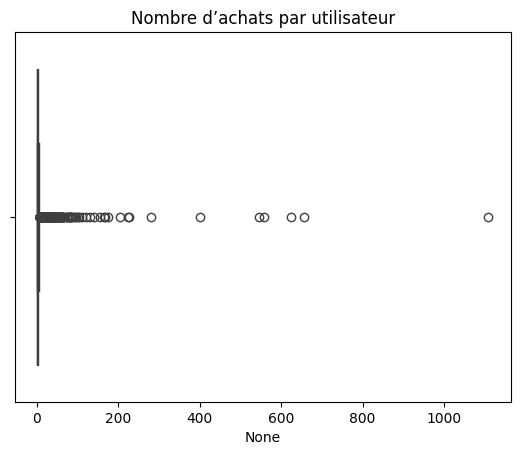

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=purchases_per_user)
plt.title("Nombre d’achats par utilisateur")
plt.show()


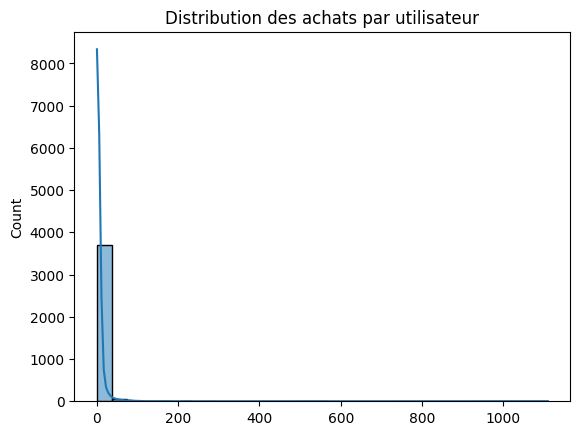

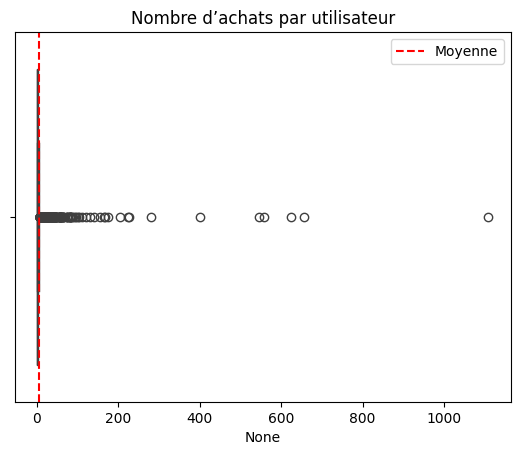

(count    3777.000000
 mean        5.559968
 std        30.192202
 min         1.000000
 25%         1.000000
 50%         1.000000
 75%         3.000000
 max      1109.000000
 dtype: float64,
 np.float64(1.0),
 np.float64(1.0),
 np.float64(3.0),
 np.float64(2.0),
 0,
 np.float64(6.0))

In [32]:
sns.histplot(purchases_per_user, bins=30, kde=True)
plt.title("Distribution des achats par utilisateur")
plt.show()
ax = sns.boxplot(x=purchases_per_user)
ax.axvline(purchases_per_user.mean(), color="red", linestyle="--", label="Moyenne")
ax.legend()
plt.title("Nombre d’achats par utilisateur")
plt.show()

summary = purchases_per_user.describe()
q1 = purchases_per_user.quantile(0.25)
median = purchases_per_user.quantile(0.50)
q3 = purchases_per_user.quantile(0.75)
iqr = q3 - q1
whisker_hi = q3 + 1.5 * iqr
whisker_lo = max(0, q1 - 1.5 * iqr)  # pas de négatif pour des comptes

summary, q1, median, q3, iqr, whisker_lo, whisker_hi




In [33]:
q99 = purchases_per_user.quantile(0.99)
outliers = purchases_per_user[purchases_per_user > whisker_hi]
prop_outliers = len(outliers) / len(purchases_per_user)

top10 = purchases_per_user.nlargest(10)
(q99, prop_outliers, top10.tolist())


(np.float64(62.47999999999956),
 0.13423351866560762,
 [1109, 656, 623, 557, 545, 401, 281, 226, 223, 204])

In [34]:
prop_1_or_less = (purchases_per_user <= 1).mean()
prop_2_or_less = (purchases_per_user <= 2).mean()
prop_5_or_less = (purchases_per_user <= 5).mean()
(prop_1_or_less, prop_2_or_less, prop_5_or_less)


(np.float64(0.5978289647868679),
 np.float64(0.7193539846438973),
 np.float64(0.8477627746889065))

In [35]:
lower_bound = mean_purchases - 2 * std_purchases
upper_bound = mean_purchases + 2 * std_purchases

outlier_users = purchases_per_user[
    (purchases_per_user < lower_bound) |
    (purchases_per_user > upper_bound)
]

outlier_users.head()


user_id
AE2TA5GQH4JI5RQ4W5H5PQOVYBGA     94
AE7BV6IMNPZ3F266H7PXMH3BZQNQ    545
AEWRZLS7FBAX3BXANLXDKVV33CCA     74
AEZ26WGWJ3EOQ4KWSHG77HJAG4EA    141
AFAIJYOUO3NAWLBDIKTQSC3DASWA    167
dtype: int64

In [36]:
product_rating_stats = df_all.groupby("parent_asin")["rating"].agg(
    mean_rating="mean",
    std_rating="std",
    count="count"
)

product_rating_stats.head()


,mean_rating,std_rating,count
parent_asin,,,
0001529145,5.0,NaN,1
0005096421,5.0,NaN,1
0005441382,5.0,NaN,1
0006920055,5.0,NaN,1
0007139667,5.0,NaN,1


In [37]:
df_all.columns


Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase', 'category'],
      dtype='object')

In [38]:
duplicates = df_all.duplicated().sum()
duplicates


np.int64(10)

In [39]:
df_all = df_all.drop_duplicates()


In [40]:
df_all["date"] = pd.to_datetime(df_all["timestamp"], unit="ms")
df_all["month"] = df_all["date"].dt.to_period("M")


In [41]:
ratings_over_time = df_all.groupby("month")["rating"].mean()

ratings_over_time.plot()
plt.title("Évolution moyenne des notes dans le temps")
plt.show()


In [23]:
df_all.isna().sum().sort_values(ascending=False)


rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
category             0
date                 0
month                0
dtype: int64

In [42]:
df_dropna = df_all.dropna()


In [43]:
df_mean = df_all.copy()
df_mean["rating"] = df_mean["rating"].fillna(df_mean["rating"].mean())


In [44]:
from sklearn.impute import KNNImputer

num_cols = df_all.select_dtypes(include="number").columns

imputer = KNNImputer(n_neighbors=5)
df_knn = df_all.copy()
df_knn[num_cols] = imputer.fit_transform(df_knn[num_cols])


In [45]:
df_model = df_knn[[
    "user_id",
    "parent_asin",
    "rating",
    "timestamp"
]].copy()

df_model.head()


,user_id,parent_asin,rating,timestamp
0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B083NRGZMM,3.0,1.658185e+12
1,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B07N69T6TM,1.0,1.592679e+12
2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,B01G8JO5F2,5.0,1.523093e+12
3,AGGZ357AO26RQZVRLGU4D4N52DZQ,B001OC5JKY,5.0,1.290278e+12
4,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,B07CJYMRWM,5.0,1.676602e+12
